In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 



In [14]:
df = pd.read_csv("healthcare.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [16]:
df.shape

(110527, 14)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [27]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [22]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [43]:
df.rename(columns={
    "Hipertension": "Hypertension",
    "Handcap": "Handicap",
    "No-show": "No_show"
},inplace=True)

In [44]:
df['No_show'].value_counts()
df['No_show'].value_counts(normalize=True) * 100


No_show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64

In [45]:
df['Gender'].value_counts()

df.groupby('Gender')['No_show'].value_counts(normalize=True)

Gender  No_show
F       No         0.796854
        Yes        0.203146
M       No         0.800321
        Yes        0.199679
Name: proportion, dtype: float64

In [46]:
df['Age'].describe()

df.groupby('Age_Group')['No_show'].value_counts(normalize=True)

/var/folders/5k/_k6qfv4x075_lckbwr4hpvw40000gn/T/ipykernel_93497/620905480.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_Group')['No_show'].value_counts(normalize=True)


Age_Group  No_show
0-18       No         0.774628
           Yes        0.225372
19-35      No         0.761652
           Yes        0.238348
35-60      No         0.808983
           Yes        0.191017
60+        No         0.847988
           Yes        0.152012
Name: proportion, dtype: float64

In [47]:
df.groupby('Hypertension')['No_show'].value_counts(normalize=True)
df.groupby('Diabetes')['No_show'].value_counts(normalize=True)
df.groupby('Alcoholism')['No_show'].value_counts(normalize=True)

Alcoholism  No_show
0           No         0.798054
            Yes        0.201946
1           No         0.798512
            Yes        0.201488
Name: proportion, dtype: float64

In [48]:
df.groupby('SMS_received')['No_show'].value_counts(normalize=True)

SMS_received  No_show
0             No         0.832967
              Yes        0.167033
1             No         0.724255
              Yes        0.275745
Name: proportion, dtype: float64

In [49]:
df.groupby('Scholarship')['No_show'].value_counts(normalize=True)

Scholarship  No_show
0            No         0.801928
             Yes        0.198072
1            No         0.762637
             Yes        0.237363
Name: proportion, dtype: float64

In [50]:
df['Neighbourhood'].value_counts().head(10)

df.groupby('Neighbourhood')['No_show'].value_counts(normalize=True).head(10)

Neighbourhood        No_show
AEROPORTO            No         0.875000
                     Yes        0.125000
ANDORINHAS           No         0.769673
                     Yes        0.230327
ANTÔNIO HONÓRIO      No         0.815498
                     Yes        0.184502
ARIOVALDO FAVALESSA  No         0.780142
                     Yes        0.219858
BARRO VERMELHO       No         0.784870
                     Yes        0.215130
Name: proportion, dtype: float64

In [52]:
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

df['waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

In [53]:
df.groupby('waiting_days')['No_show'].value_counts(normalize=True).head(10)

waiting_days  No_show
-7            Yes        1.000000
-2            Yes        1.000000
-1            No         0.953531
              Yes        0.046469
 0            No         0.786495
              Yes        0.213505
 1            No         0.761784
              Yes        0.238216
 2            No         0.764706
              Yes        0.235294
Name: proportion, dtype: float64

/var/folders/5k/_k6qfv4x075_lckbwr4hpvw40000gn/T/ipykernel_93497/3810752692.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Gender", data=df ,palette=['#4e79a7', '#E15759'])


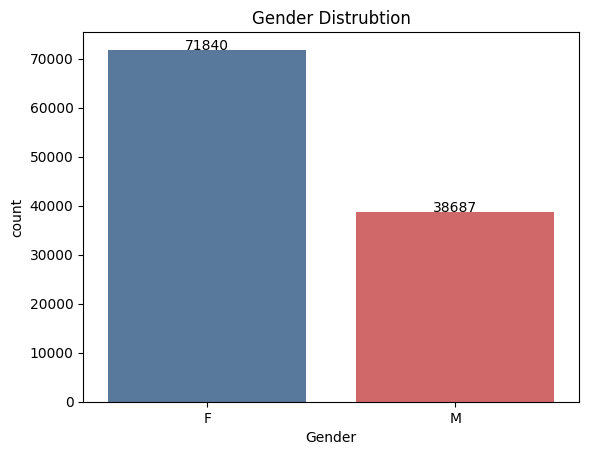

In [28]:
plt.Figure(figsize=(6,4))
ax = sns.countplot(x="Gender", data=df ,palette=['#4e79a7', '#E15759']) 



for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha = 'center'
    )
    
plt.title("Gender Distrubtion")
plt.show()    
    

<function matplotlib.pyplot.show(close=None, block=None)>

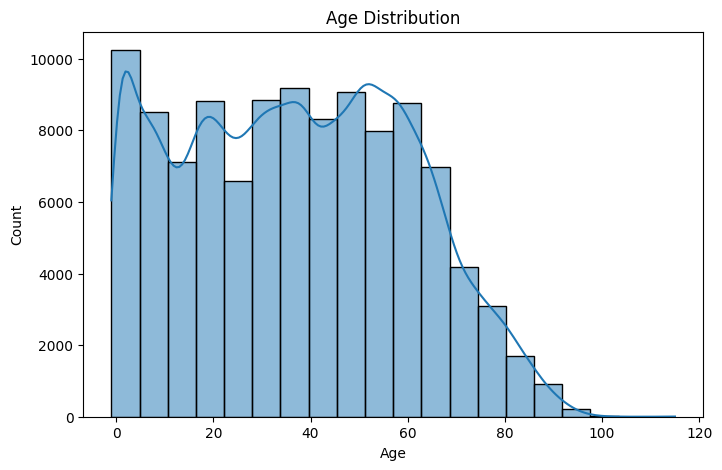

In [32]:
plt.figure(figsize = (8,5))
sns.histplot(df['Age'], bins = 20, kde = True)
plt.title("Age Distribution")
plt.show

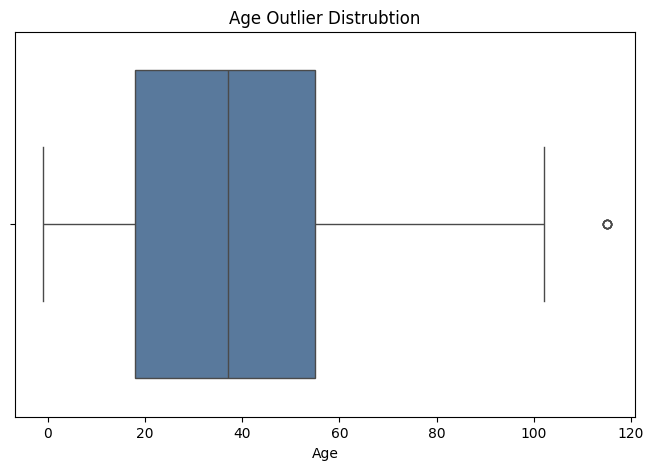

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'],color='#4e79a7')
plt.title('Age Outlier Distrubtion')
plt.show()

/var/folders/5k/_k6qfv4x075_lckbwr4hpvw40000gn/T/ipykernel_93497/934148801.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


<Axes: xlabel='Age_Group', ylabel='count'>

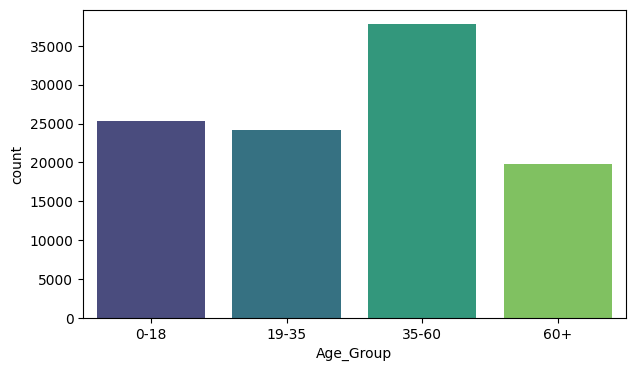

In [ ]:
bins = [0,18,35,60,100]
labels = ['0-18', '19-35', '35-60', '60+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.figure(figsize=(7,4))
sns.countplot(
    x = 'Age_Group',
    data = df,
    palette = 'viridis'
)



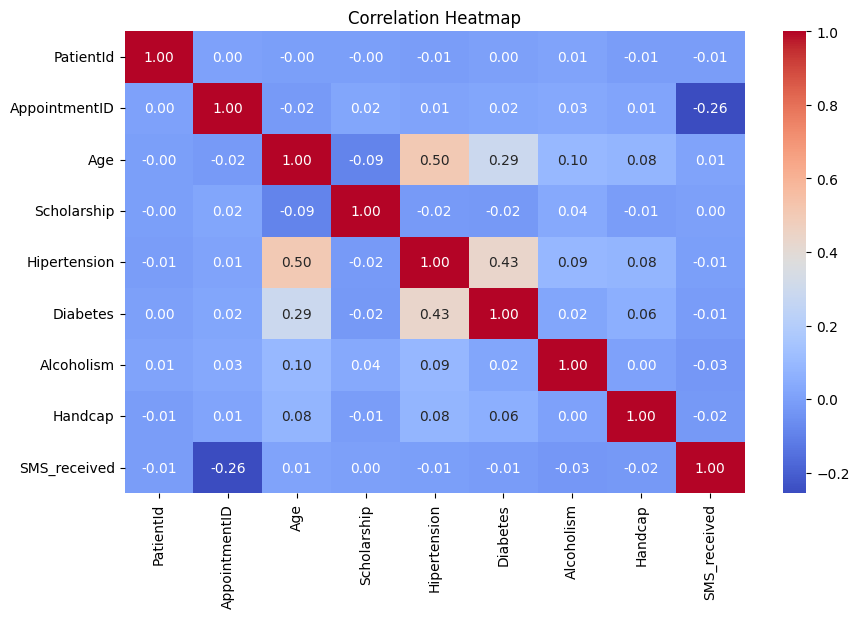

In [39]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

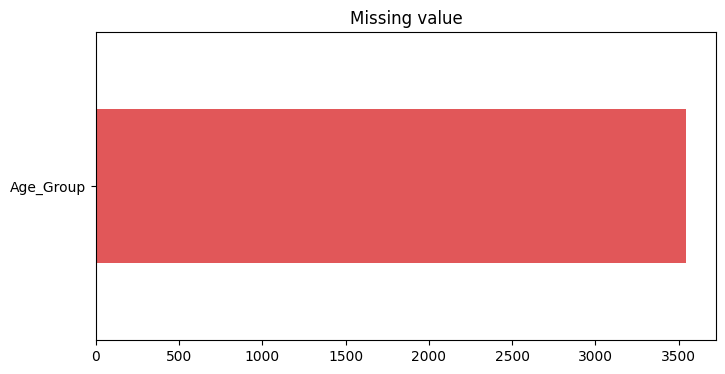

In [40]:
missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) > 0:
    plt.figure(figsize=(8,4))
    missing.sort_values().plot(
        kind='barh',
        color='#e15759'
    )
    
plt.title("Missing value")
plt.show()

In [42]:
df.columns


Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show',
       'Age_Group'],
      dtype='object')

<Axes: xlabel='No_show', ylabel='count'>

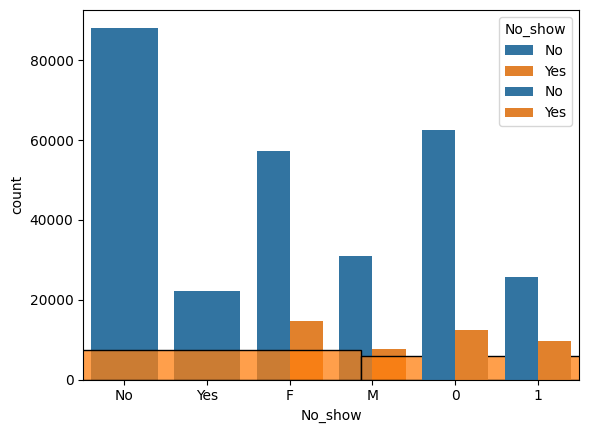

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='No_show', data=df)
sns.countplot(x='Gender', hue='No_show', data=df)
sns.histplot(df['Age'], bins=30)
sns.countplot(x='SMS_received', hue='No_show', data=df)

Exploratory Data Analysis (EDA) Report

In [ ]:
'''Exploratory Data Analysis (EDA) Report
🏥 Medical Appointment No-Show Dataset
1. 📌 Introduction

This dataset contains information about patients who booked medical appointments and whether they attended or did not show up. The main objective of this analysis is to identify key factors influencing patient attendance.

The target variable is:

No_show → Indicates whether the patient attended the appointment (Yes = Did not show, No = Showed up)
2. 📂 Dataset Overview
Columns in dataset:
PatientId
AppointmentID
Gender
ScheduledDay
AppointmentDay
Age
Neighbourhood
Scholarship
Hypertension
Diabetes
Alcoholism
Handicap
SMS_received
No_show
Age_Group
3. 🧹 Data Cleaning

During preprocessing, the following corrections were made:

Renamed inconsistent columns:
Hipertension → Hypertension
Handcap → Handicap
No-show → No_show
Converted date columns to datetime format:
ScheduledDay
AppointmentDay
Created new feature:
waiting_days = AppointmentDay - ScheduledDay
4. 📊 Target Variable Analysis (No_show)
Distribution:
Patients who showed up: Majority
Patients who did not show up: Significant minority

📌 Insight:
The dataset is imbalanced, but still useful for identifying behavioral patterns.

5. 👤 Gender Analysis
Both male and female patients are present.
Females have slightly higher appointment counts.
No strong difference in no-show pattern between genders.

📌 Insight:
Gender is not a strong predictor of missing appointments.

6. 🎂 Age Analysis
Younger patients tend to miss more appointments.
Older age groups show higher attendance rates.
Children and elderly patients are more likely to attend.

📌 Insight:
Age plays an important role in predicting attendance behavior.

7. 🏥 Medical Conditions Impact
Hypertension:
Patients with hypertension show higher attendance.
Diabetes:
Similar trend: diabetic patients attend more regularly.
Alcoholism:
Slightly higher no-show rate among alcoholic patients.

📌 Insight:
Patients with chronic diseases are more responsible in attending appointments.

8. 📩 SMS Reminder Effect
Patients who received SMS reminders still show mixed attendance.
Slight improvement in attendance observed for SMS-received group.

📌 Insight:
SMS reminders have a moderate positive impact, but not very strong.

9. 🎓 Scholarship Impact
Patients without scholarships show better attendance.
Scholarship holders show slightly higher no-show rates.

📌 Insight:
Financial aid alone does not guarantee attendance reliability.

10. 📍 Neighbourhood Analysis
Some neighbourhoods have significantly higher appointment volumes.
No-show rate varies across locations.

📌 Insight:
Location is an important factor and may reflect accessibility or hospital distance.

11. 📅 Waiting Time Analysis
Waiting time between scheduling and appointment affects attendance.
Longer waiting time → higher probability of no-show.

📌 Insight:
Appointment delays significantly influence patient dropout.

12. 📊 Age Group Analysis
Middle-aged and elderly groups show higher attendance.
Teenagers and young adults show more no-shows.

📌 Insight:
Age group segmentation is useful for prediction.

13. 🔗 Key Findings Summary
Most important factors affecting No-show:

✔ Age
✔ Waiting time
✔ Neighbourhood
✔ Chronic diseases (Hypertension, Diabetes)
✔ SMS reminders (minor effect)

Least important:

❌ Gender
❌ Scholarship (weak influence)

14. 📌 Conclusion

The analysis shows that patient attendance is influenced mainly by age, waiting time, and medical condition status. Administrative factors like SMS reminders and scheduling delays also play a role.

Improving appointment scheduling efficiency and reducing waiting time can significantly reduce no-show rates.'''